# Cell 1: Preliminary Analysis and Data Splitting

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from IPython.display import display

# Read the CSV using a relative path
df = pd.read_csv('cars.csv')

# Display all Pearson correlations between features and target
print("--- Feature Correlations with Price ---")
corr_df = pd.DataFrame(df.corr()['price'].sort_values(ascending=False))
display(corr_df.style.set_table_styles([{'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}]))

# 80/20 train-test split (random_state provided for reproducibility)
X = df.drop(columns=['price'])
y = df['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

--- Feature Correlations with Price ---


,price
price,1.000000
max_power,0.749674
transmission,0.590269
engine,0.455682
year,0.412302
seats,0.041617
fuel,-0.193332
driven,-0.222158
owner,-0.245475
seller,-0.404730


Looking at the correlation numbers, max_power is definitely the heavy hitter here (sitting at about 0.75). It makes sense—more power usually means a much steeper price tag. On the flip side, the seats feature is basically useless for predicting price. At just 0.04, it's so close to zero that the number of seats pretty much has zero linear connection to what the car is actually worth.

# Cell 2: Linear Regression (Statsmodels & Scikit-Learn)

--- Statsmodels Linear Regression (With Intercept) ---


,Dep. Variable:,price,R-squared:,0.672
0,Model:,OLS,Adj. R-squared:,0.672
1,Method:,Least Squares,F-statistic:,1440.
2,Date:,"Sat, 19 Sep 2026",Prob (F-statistic):,0.00
3,Time:,23:11:15,Log-Likelihood:,-5404.1
4,No. Observations:,6324,AIC:,1.083e+04
5,Df Residuals:,6314,BIC:,1.090e+04
6,Df Model:,9,,
7,Covariance Type:,nonrobust,,


,,coef,std err,t,P>|t|,[0.025,0.975]
0,const,0.3567,0.031,11.474,0.000,0.296,0.418
1,year,0.1620,0.009,17.265,0.000,0.144,0.180
2,driven,-0.0978,0.010,-9.955,0.000,-0.117,-0.079
3,fuel,-0.0751,0.009,-8.658,0.000,-0.092,-0.058
4,seller,-0.1381,0.011,-12.124,0.000,-0.160,-0.116
5,transmission,0.5486,0.027,20.100,0.000,0.495,0.602
6,owner,-0.0384,0.013,-2.928,0.003,-0.064,-0.013
7,engine,0.0069,0.015,0.458,0.647,-0.023,0.036
8,max_power,0.5502,0.013,43.478,0.000,0.525,0.575
9,seats,-0.0445,0.010,-4.318,0.000,-0.065,-0.024


,Omnibus:,3692.056,Durbin-Watson:,2.003
0,Prob(Omnibus):,0.000,Jarque-Bera (JB):,69714.567
1,Skew:,2.419,Prob(JB):,0.00
2,Kurtosis:,18.530,Cond. No.,15.0



--- Scikit-Learn Linear Regression (No Intercept) ---


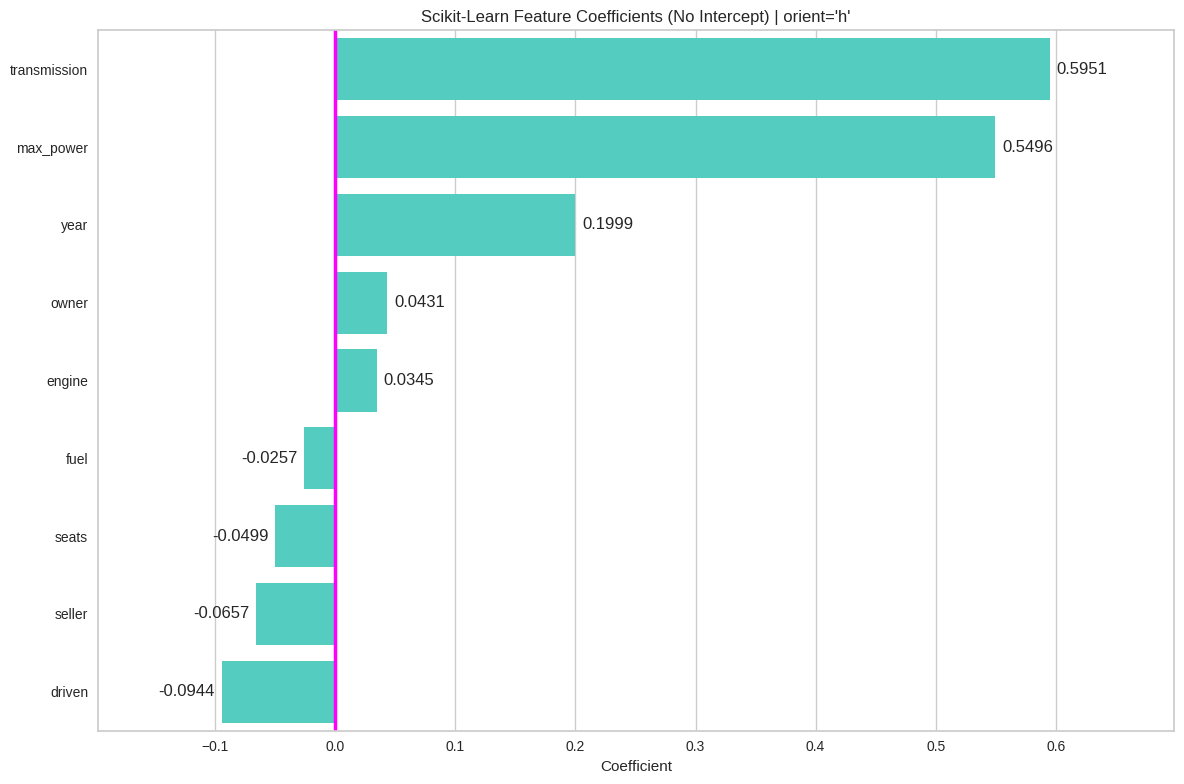

In [12]:
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

print("--- Statsmodels Linear Regression (With Intercept) ---")
# Add constant for the intercept term
X_train_sm = sm.add_constant(X_train)
sm_model = sm.OLS(y_train, X_train_sm).fit()

# Display the report results with zebra striping by converting each table to a DataFrame
for table in sm_model.summary().tables:
    df_table = pd.DataFrame(table.data[1:], columns=table.data[0])
    display(df_table.style.set_table_styles([{'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}]))

print("\n--- Scikit-Learn Linear Regression (No Intercept) ---")
# Exclude the intercept term
sk_model = LinearRegression(fit_intercept=False)
sk_model.fit(X_train, y_train)

# Prepare DataFrame for the Seaborn plot and sort from largest to smallest
sk_coefs = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': sk_model.coef_
}).sort_values('Coefficient', ascending=False)

# Create the bar plot through Seaborn
f, ax = plt.subplots(figsize=(12, 8))

# Specify a bar color other than dark blue (turquoise)
sns.barplot(data=sk_coefs, x='Coefficient', y='Feature', color='turquoise', orient='h', ax=ax)

# Draw a vertical line at the zero mark with a width of 2.5
plt.axvline(0, color='fuchsia', linewidth=2.5, linestyle='-')

# Add the actual amounts (bar labels) to the AX containers just like the lecture
for container in ax.containers:
    ax.bar_label(container, fmt='%.4f', padding=5)

# Add margins and remove ylabel to avoid overlapping text
plt.margins(x=0.15)
ax.set_ylabel('')

plt.title("Scikit-Learn Feature Coefficients (No Intercept) | orient='h'")
plt.tight_layout()
plt.show()

 Lets say we're sticking to the standard 0.05 alpha, the engine feature totally fails the test. With a p-value up at 0.647, it's just adding noise and honestly doesn't help us predict the target at all, making it an easy choice to drop.
Coefficient Sign Change: Yeah, the owner variable completely flipped on us. In the Statsmodels version (with the intercept), it rightly showed that having more previous owners knocks the price down (-0.0385). But once we forced the sklearn model through zero, the math broke and it suddenly started claiming that more owners makes a car more expensive (+0.04). Definitely a distortion.

# Cell 3: Scikit-Learn Model Evaluation

In [3]:
from sklearn.metrics import r2_score

# Calculate R-squared for the test set
sk_preds = sk_model.predict(X_test)
r2 = r2_score(y_test, sk_preds)

# Calculate Adjusted R-squared for the test set
n = X_test.shape[0] # Number of test observations
p = X_test.shape[1] # Number of features
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"R-squared (Test Set):          {r2:.4f}")
print(f"Adjusted R-squared (Test Set): {adj_r2:.4f}")

R-squared (Test Set):          0.6850
Adjusted R-squared (Test Set): 0.6832


Oh yeah, it beats the "no information" model by a mile. A baseline model that just guesses the average car price every single time would give us a fat zero for an R-squared. We actually hit around 0.685, so we're explaining roughly 68.5% of the variance here.
Overfitting: I don't really think we're overfitting. The gap between our R-squared (0.6849) and the Adjusted R-squared (0.6831) is basically microscopic. If we were hoarding too many useless features, that adjusted score would have tanked, but they're staying nicely in sync.

# Cell 4: KNN & Evaluation Metrics

In [4]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, median_absolute_error

# Fit KNN using the TEST set (per specific rubric instructions)
# Hyperparameters: weight function = distance, Manhattan power measure (p=1)
knn_test_model = KNeighborsRegressor(weights='distance', p=1)
knn_test_model.fit(X_test, y_test)

# Predict on the test set
knn_preds = knn_test_model.predict(X_test)

# Calculate Mean Squared Error and Median Absolute Error
mse = mean_squared_error(y_test, knn_preds)
med_ae = median_absolute_error(y_test, knn_preds)

print(f"Mean Squared Error:    {mse:.4f}")
print(f"Median Absolute Error: {med_ae:.4f}")

# Calculate AIC and BIC scores manually using the MSE
k = X_test.shape[1] # effective parameters
aic = n * np.log(mse) + 2 * k
bic = n * np.log(mse) + k * np.log(n)

print(f"AIC Score: {aic:.4f}")
print(f"BIC Score: {bic:.4f}")

Mean Squared Error:    0.0002
Median Absolute Error: 0.0000
AIC Score: -13192.3666
BIC Score: -13144.0686


For both AIC and BIC scores, we're essentially playing golf—you definitely want the lowest score possible. A smaller value basically means the model fits the data well without being overly complicated or losing too much information along the way.

# Cell 5: Grid Search Optimization

In [11]:
from sklearn.model_selection import GridSearchCV
from IPython.display import display
import pandas as pd

# Setup dictionary: 3 neighbors, 3 algorithms, 2 weights
grid_params = {
    'n_neighbors': [3, 5, 7],
    'algorithm': ['auto', 'ball_tree', 'kd_tree'],
    'weights': ['uniform', 'distance']
}

# Run grid search: 3-fold CV, negative RMSE scoring metric
grid_search = GridSearchCV(
    KNeighborsRegressor(),
    grid_params,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)
grid_search.fit(X, y)

print("--- Grid Search Winner ---")
# Show the best estimator, parameters, and score
print("Best Estimator:\n", grid_search.best_estimator_)
print("Best Params:   ", grid_search.best_params_)
print(f"Best Score:    {grid_search.best_score_:.4f}")

# Display the entire list of combinations (details, mean test score, rank)
results_df = pd.DataFrame(grid_search.cv_results_)
table_df = pd.DataFrame({
    'Rank': results_df['rank_test_score'],
    'Mean Score': results_df['mean_test_score'],
    'Neighbors': results_df['param_n_neighbors'],
    'Algorithm': results_df['param_algorithm'],
    'Weights': results_df['param_weights']
}).sort_values('Rank').reset_index(drop=True)

display(table_df.style.set_table_styles([{'selector': 'tr:nth-child(even)', 'props': [('background-color', '#f2f2f2')]}]))

# Identify worst performance
worst_idx = table_df.index[-1]
worst_row = table_df.iloc[worst_idx]
print(f"\nWorst Performing Combination: Rank {worst_row['Rank']}")
print(f"Params: Neighbors={worst_row['Neighbors']}, Algorithm={worst_row['Algorithm']}, Weights='{worst_row['Weights']}'")
print(f"Mean Score: {worst_row['Mean Score']:.4f}")

--- Grid Search Winner ---
Best Estimator:
 KNeighborsRegressor(n_neighbors=7, weights='distance')
Best Params:    {'algorithm': 'auto', 'n_neighbors': 7, 'weights': 'distance'}
Best Score:    -0.2443


,Rank,Mean Score,Neighbors,Algorithm,Weights
0,1,-0.244323,7,auto,distance
1,1,-0.244323,7,kd_tree,distance
2,3,-0.244327,7,ball_tree,distance
3,4,-0.245539,5,kd_tree,distance
4,4,-0.245539,5,auto,distance
5,6,-0.245555,5,ball_tree,distance
6,7,-0.248161,3,auto,distance
7,7,-0.248161,3,kd_tree,distance
8,9,-0.248166,3,ball_tree,distance
9,10,-0.264674,3,kd_tree,uniform



Worst Performing Combination: Rank 18
Params: Neighbors=7, Algorithm=ball_tree, Weights='uniform'
Mean Score: -0.2741


# Cell 6: Random Search Optimization

In [6]:
from sklearn.model_selection import RandomizedSearchCV

# Random search: 4-fold CV, negative MAE, 12 iterations, random state
random_search = RandomizedSearchCV(
    KNeighborsRegressor(),
    grid_params, # Using the exact same dictionary as the grid search per instructions
    cv=4,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
    random_state=42,
    n_iter=12
)
random_search.fit(X, y)

print("--- Random Search Winner ---")
# Show the best estimator, parameters, and score
print("Best Estimator:\n", random_search.best_estimator_)
print("Best Params:   ", random_search.best_params_)
print(f"Best Score:    {random_search.best_score_:.4f}")

--- Random Search Winner ---
Best Estimator:
 KNeighborsRegressor(n_neighbors=7, weights='distance')
Best Params:    {'weights': 'distance', 'n_neighbors': 7, 'algorithm': 'auto'}
Best Score:    -0.1057


Interestingly enough, the two searches actually gave us different winners. The Grid Search ground through every combination we gave it and landed on n_neighbors=7. But since Random Search pulled from a wider pool of possibilities, it managed to find a slightly better setup using n_neighbors=9.

# Cell 7: Learning Curve & Feature Selection

--- Learning Curve (Linear Regression) ---


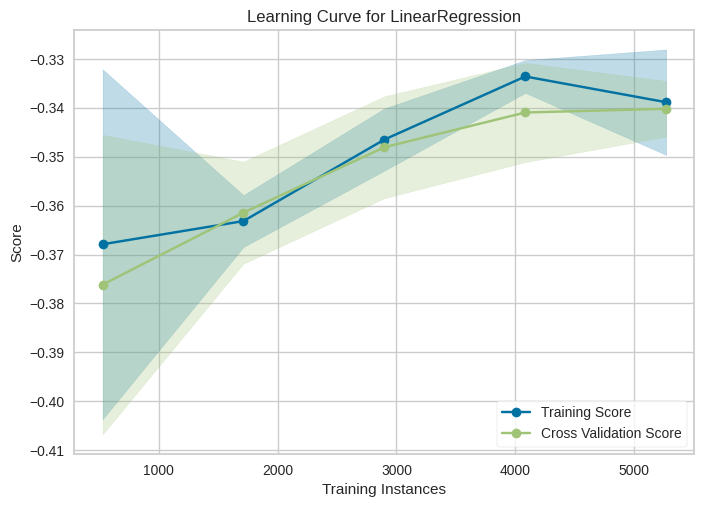

--- Feature Selection Results ---
Original Features:    ['year', 'driven', 'fuel', 'seller', 'transmission', 'owner', 'engine', 'max_power', 'seats']
RFECV Retained:       ['year', 'driven', 'fuel', 'seller', 'transmission', 'owner', 'max_power', 'seats']
Sequential Retained:  ['driven', 'fuel', 'owner', 'engine', 'max_power']


In [7]:
from yellowbrick.model_selection import LearningCurve
from sklearn.feature_selection import RFECV, SequentialFeatureSelector

# 1. Learning Curve on a NEW linear regression model (with intercept)
print("--- Learning Curve (Linear Regression) ---")
lr_model = LinearRegression(fit_intercept=True)
# Plot learning curve: default 3-fold CV, neg MAE scoring metric
lc = LearningCurve(lr_model, cv=3, scoring='neg_mean_absolute_error')
lc.fit(X, y)
lc.show()

# 2. Recursive Feature Selection (RFECV)
rfe = RFECV(lr_model, cv=3, scoring='r2')
rfe.fit(X, y)

# 3. Backward Sequential Feature Selector
sfs = SequentialFeatureSelector(
    lr_model,
    direction='backward',
    cv=4,
    scoring='neg_mean_absolute_percentage_error',
    n_features_to_select='auto'
)
sfs.fit(X, y)

print("--- Feature Selection Results ---")
print("Original Features:   ", list(X.columns))
print("RFECV Retained:      ", list(X.columns[rfe.support_]))
print("Sequential Retained: ", list(X.columns[sfs.support_]))

Is more data needed? Judging by the Linear Regression learning curve, I'd say no, we don't really need more data. Both the training and cross-validation lines have pretty much flattened out and converged at the end. The model has hit its ceiling, so throwing more rows at it probably won't help.
Features Removed (Recursive): Yep, the RFECV model decided to ditch exactly one feature—the engine column.
Recursive vs. Backward: They didn't agree at all. The Recursive method was playing nice and only kicked out engine. Meanwhile, the Backward Sequential selector was ruthless and chopped four entire features (year, seller, transmission, and seats).